# Cyclistic bike-share: data analysis case study

The following are some data extraction and preparation steps, performed on the historical data at: __https://divvy-tripdata.s3.amazonaws.com/index.html__


Question to be addresssed by the data analysis: **How do annual members and casual riders use Cyclistic bikes differently?**


In [1]:
# Import libraries to be used in the data processing steps

import pandas as pd
import numpy as np
import datetime

## Extract data from source

The separate data files, where each month's data is saved in an individual .csv file, are loaded as dataframes into a dictionary (`df_sep`). The loop only loads the previous 4 month's data, but could be altered e.g. to load the previous 12 month's data.

In [2]:
# Load the required data files with a loop, from folder "GoogleDataCap"

df_sep = {}
curr_month = datetime.datetime.now().month-1
curr_yr = datetime.datetime.now().year

for i in range(curr_month-4, curr_month, 1):
    if i <= 0:
        filename = f'GoogleDataCap/{curr_yr-1}{i+12:02}-divvy-tripdata.csv'
        df_name = f'M{i+12:02}_{curr_yr-2001}'
    else:
        filename = f'GoogleDataCap/{curr_yr}{i:02}-divvy-tripdata.csv'
        df_name = f'M{i:02}_{curr_yr-2000}'

    df_sep[df_name] = pd.read_csv(filename)

### Preliminary data quality checks

Check that the dataframes in `df_sep` are consistent, e.g. same number of columns appearing in the same order, same column names, etc.

In [3]:
for i in df_sep.keys():
    print(f'{i} has {len(df_sep[i].columns)} columns')

M11_25 has 13 columns
M12_25 has 13 columns
M01_26 has 13 columns
M02_26 has 13 columns


In [4]:
# Check if the column names are the same

comparison_matrix = [[0 for i in range(len(df_sep))] for j in range(3)]

m1_key = list(df_sep.keys())[0]
m1_col_Ser = pd.Series(df_sep[m1_key].columns)
m1_col_set = set(df_sep[m1_key].columns)
f_order = False
f_names = False

for i, m2_key in enumerate(df_sep.keys()):
    m2_col_Ser = pd.Series(df_sep[m2_key].columns)
    order_diff = sum(m2_col_Ser != m1_col_Ser) 

    if order_diff != 0:   # True (>0) if the ordered column name lists from the two dataframes do not match
        f_order = True
        comparison_matrix[0][i] = m1_key + ' vs. ' + m2_key
        comparison_matrix[1][i] = order_diff
        comparison_matrix[2][i] = 'review column order'
    
        m2_col_set = set(df_sep[m2_key].columns)
        name_diff = m2_col_set - m1_col_set
    
        if len(name_diff) != 0:   # True (>0) if the unordered column name lists from the two dataframes also do not match
            f_names = True
            comparison_matrix[2][i] = name_diff

if sum(comparison_matrix[1]) == 0:
    print('\nAll column names are consistent')
else:
    if f_order and not(f_names):
        print('\nDataframes have the same column names but not in the same order. Number of differences:\n', 
              comparison_matrix[0], comparison_matrix[1], sep='\n')
    else:
        print('\nColumn names are different and/or not in the same order. Review the following:\n', 
              comparison_matrix[0], comparison_matrix[2], sep='\n')


All column names are consistent



### Combine data into a single data frame

After checking that the dataframes are consistent, combine them into a single large dataframe (`all_trips`). Perform some preliminary data quality checks in order to determine which cleaning/transformation steps are necessary.

In [5]:
all_trips = pd.DataFrame()

for i in df_sep.keys():
    all_trips = pd.concat([all_trips, df_sep[i]], ignore_index=True)

print(f'Size of combined dataframe: {all_trips.shape[0]:,} rows, {all_trips.shape[1]}  columns')

Size of combined dataframe: 836,399 rows, 13  columns


## Exploratory data analysis

View some information about the data such as a preview of the first few entries, dataframe structure, column data types, number of null and duplicate entries in some columns, descriptive stats, etc.

In [6]:
all_trips.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E555D9F8E9C2F56B,electric_bike,2025-11-04 00:09:07.792,2025-11-04 00:15:04.661,NaN,NaN,NaN,NaN,41.94,-87.67,41.94,-87.67,casual
1,EAEBE70DBF015886,electric_bike,2025-11-04 14:32:09.067,2025-11-04 14:36:43.998,NaN,NaN,NaN,NaN,41.90,-87.64,41.91,-87.64,casual
2,A42F8404F804E56E,electric_bike,2025-11-04 12:20:48.215,2025-11-04 12:21:01.630,NaN,NaN,NaN,NaN,41.89,-87.63,41.89,-87.63,casual
3,E49D01E38A1E074E,electric_bike,2025-11-04 12:17:16.548,2025-11-04 12:17:51.527,NaN,NaN,NaN,NaN,41.89,-87.63,41.89,-87.63,casual
4,9308F609195D2414,electric_bike,2025-11-04 08:16:27.979,2025-11-04 08:21:02.780,NaN,NaN,NaN,NaN,41.89,-87.64,41.88,-87.64,casual


In [7]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836399 entries, 0 to 836398
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             836399 non-null  object 
 1   rideable_type       836399 non-null  object 
 2   started_at          836399 non-null  object 
 3   ended_at            836399 non-null  object 
 4   start_station_name  676571 non-null  object 
 5   start_station_id    676571 non-null  object 
 6   end_station_name    662002 non-null  object 
 7   end_station_id      662002 non-null  object 
 8   start_lat           836399 non-null  float64
 9   start_lng           836399 non-null  float64
 10  end_lat             835595 non-null  float64
 11  end_lng             835595 non-null  float64
 12  member_casual       836399 non-null  object 
dtypes: float64(4), object(9)
memory usage: 83.0+ MB


In [8]:
print('Number of unique entries in each column: \n\n', all_trips.nunique(), sep='')

Number of unique entries in each column: 

ride_id               836399
rideable_type              2
started_at            836333
ended_at              835558
start_station_name      1503
start_station_id        1497
end_station_name        1507
end_station_id          1504
start_lat              26754
start_lng              26658
end_lat                 1570
end_lng                 1566
member_casual              2
dtype: int64


In [9]:
print('Number of missing/null entries in each column:\n\n', all_trips.isnull().sum(), sep='')

Number of missing/null entries in each column:

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    159828
start_station_id      159828
end_station_name      174397
end_station_id        174397
start_lat                  0
start_lng                  0
end_lat                  804
end_lng                  804
member_casual              0
dtype: int64


In [10]:
print('Descriptive stats for numerical entries:\n\n', all_trips.describe(), sep='')

Descriptive stats for numerical entries:

           start_lat      start_lng        end_lat        end_lng
count  836399.000000  836399.000000  835595.000000  835595.000000
mean       41.900621     -87.647038      41.900908     -87.647376
std         0.046563       0.027173       0.046722       0.027370
min        41.648501     -87.890000      41.590000     -88.100000
25%        41.880317     -87.660141      41.880317     -87.661198
50%        41.894877     -87.642884      41.895687     -87.642900
75%        41.926277     -87.630000      41.926940     -87.630000
max        42.070000     -87.520000      42.090000     -87.520000


View the categories for the `rideable_type` and `member_casual` columns:

In [11]:
print('Number of each rideable type: \n\n', all_trips.rideable_type.value_counts(), sep='')

Number of each rideable type: 

rideable_type
electric_bike    565214
classic_bike     271185
Name: count, dtype: int64


In [12]:
print('Number of each member_casual category: \n\n', all_trips.member_casual.value_counts(), sep='')

Number of each member_casual category: 

member_casual
member    643248
casual    193151
Name: count, dtype: int64


The station details columns have a significant number of missing entries. The following gives a summary of the portion of data entries with missing details.

In [13]:
all_count = len(all_trips)

start_id_null_count = len(all_trips[(all_trips['start_station_name'].isna()) & (all_trips.end_station_name.notna()) & 
    (all_trips.end_lat.notna())])

end_id_null_count = len(all_trips[(all_trips['end_station_name'].isna()) & (all_trips.start_station_name.notna()) & 
    (all_trips.end_lat.notna())])

start_end_id_null_count = len(all_trips[(all_trips['start_station_name'].isna()) & (all_trips.end_station_name.isna()) & 
    (all_trips.end_lat.notna())])

end_all_null_count = len(all_trips[(all_trips.end_station_name.isna()) & (all_trips.end_lat.isna()) & 
    (all_trips.start_station_name.notna())])

clean_count=len(all_trips[(all_trips.start_station_name.notna()) & (all_trips.end_station_name.notna()) & (all_trips.end_lat.notna())])

print('Number of trips with missing start and/or end station details:\n')

print(f'Start station name & id only: {start_id_null_count:13,} ({start_id_null_count/all_count:3.2%})')
print(f'End station name & id only: {end_id_null_count:15,} ({end_id_null_count/all_count:3.2%})')
print(f'Start & end station name & id only: {start_end_id_null_count:7,} ({start_end_id_null_count/all_count:3.2%})')
print(f'End station name, id & coordinates: {end_all_null_count:7,} ({end_all_null_count/all_count:3.2%})')
print(f'\nAll station information available: {clean_count:8,} ({clean_count/all_count:3.2%})')
print(f'\nTotal number of trips in dataset:  {all_count:8,}')

Number of trips with missing start and/or end station details:

Start station name & id only:        86,094 (10.29%)
End station name & id only:          99,859 (11.94%)
Start & end station name & id only:  73,734 (8.82%)
End station name, id & coordinates:     804 (0.10%)

All station information available:  575,908 (68.86%)

Total number of trips in dataset:   836,399


All trips with missing `start_station_name` or `start_station_id` were for the `electric_bike` category, while all trips neither `end_station_name`, `end_station_id`, `end_station_lat` nor `end_station_lng` were for the `classic_bike` category:

In [14]:
print('Rideable type for trips without start_station_name or start_station_id:\n', 
      all_trips[(all_trips['start_station_name'].isna()) & (all_trips.end_station_name.notna()) & 
          (all_trips.end_lat.notna())]['rideable_type'].value_counts(), sep='')

print('\nRideable type for trips without end_station_name, end_station_id and end_station coordinates:\n', 
      all_trips[(all_trips.end_station_id.isna()) & (all_trips.end_lat.isna())]['rideable_type'].value_counts(), sep='')

Rideable type for trips without start_station_name or start_station_id:
rideable_type
electric_bike    86094
Name: count, dtype: int64

Rideable type for trips without end_station_name, end_station_id and end_station coordinates:
rideable_type
classic_bike    804
Name: count, dtype: int64


It may be possible to infer the names/id of some unnamed stations by comparing their coordinates of the named stations' coordinates. This exercise is left out of the scope of the current project.

However, the chart below shows that some unnamed stations have no known stations with which they share coordinates.

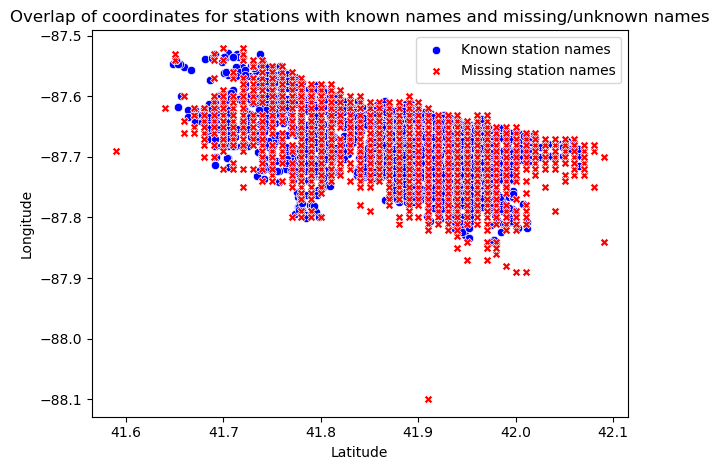

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

start_stations = all_trips[['start_station_name', 'start_station_id', 'start_lat', 'start_lng']].copy()
start_stations.columns = ['station_name', 'station_id', 'lat', 'lng']
end_stations = all_trips[['end_station_name', 'end_station_id', 'end_lat', 'end_lng']].copy()
end_stations.columns = start_stations.columns

all_stations = pd.concat([start_stations, end_stations], ignore_index=True).drop_duplicates()

known_stations = all_stations[all_stations['station_name'].notna()]

unknown_stations = all_stations[all_stations['station_name'].isna()]

fig, ax = plt.subplots()

sns.scatterplot(x=known_stations.lat, y=known_stations.lng, marker='o', color='blue', ax=ax)
sns.scatterplot(x=unknown_stations.lat, y=unknown_stations.lng, marker='X', color='red', ax=ax)
ax.set_title('Overlap of coordinates for stations with known names and missing/unknown names')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.legend(['Known station names', 'Missing station names'])

plt.tight_layout()
plt.show()

## Clean and transform the data

The decision is made to remove trips with any missing information before further analysis, creating the dataframe `clean_trips`. The `ride_length` (duration of each trip in seconds) is required per the task instructions, and also helps to later deal with data quality issues. Some summaries on a time basis is useful; hence the `day`, `month` and `year` columns are created. The `date` column is also added to later assist with creating a date dimension table.

In [16]:
clean_trips = all_trips[(all_trips.start_station_name.notna()) & (all_trips.end_station_name.notna()) & 
    (all_trips.end_lat.notna())].copy()
clean_trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575908 entries, 193 to 836398
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             575908 non-null  object 
 1   rideable_type       575908 non-null  object 
 2   started_at          575908 non-null  object 
 3   ended_at            575908 non-null  object 
 4   start_station_name  575908 non-null  object 
 5   start_station_id    575908 non-null  object 
 6   end_station_name    575908 non-null  object 
 7   end_station_id      575908 non-null  object 
 8   start_lat           575908 non-null  float64
 9   start_lng           575908 non-null  float64
 10  end_lat             575908 non-null  float64
 11  end_lng             575908 non-null  float64
 12  member_casual       575908 non-null  object 
dtypes: float64(4), object(9)
memory usage: 61.5+ MB


### Add `ride_length`:

In [17]:
clean_trips['started_at'] = pd.to_datetime(clean_trips['started_at'])
clean_trips['ended_at'] = pd.to_datetime(clean_trips['ended_at'])
clean_trips[['started_at', 'ended_at']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 575908 entries, 193 to 836398
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   started_at  575908 non-null  datetime64[ns]
 1   ended_at    575908 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 13.2 MB


In [18]:
clean_trips['ride_length'] = (clean_trips['ended_at'] - clean_trips['started_at']).dt.total_seconds()
clean_trips['ride_length'].describe()

count    575908.000000
mean        763.399791
std        2303.321166
min       -3287.688000
25%         286.482750
50%         470.084500
75%         794.593250
max       89906.901000
Name: ride_length, dtype: float64

Some `ride_length` values are negative. The stats for both numerical and categorical columns are as below, showing that all trips with negative ride lengths are on 02 November 2025, between 1 and 2 am. These trips are removed from the `clean_trips` dataframe.

In [19]:
print(f'Number of entries with negative or zero ride length: {len(clean_trips[clean_trips.ride_length <= 0])}\n')
clean_trips[clean_trips.ride_length <= 0].describe(include='all')

Number of entries with negative or zero ride length: 19



,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
count,19,19,19,19,19,19,19,19,19.000000,19.000000,19.000000,19.000000,19,19.000000
unique,19,2,NaN,NaN,18,18,17,17,NaN,NaN,NaN,NaN,2,NaN
top,5D010AFEA6850513,classic_bike,NaN,NaN,Clark St & Chicago Ave,CHI00351,Clark St & Wrightwood Ave,CHI00287,NaN,NaN,NaN,NaN,member,NaN
freq,1,12,NaN,NaN,2,2,2,2,NaN,NaN,NaN,NaN,12,NaN
mean,NaN,NaN,2025-11-02 01:50:25.164473600,2025-11-02 01:10:48.787368448,NaN,NaN,NaN,NaN,41.915277,-87.670796,41.923719,-87.678179,NaN,-2376.377105
min,NaN,NaN,2025-11-02 01:17:57.001000,2025-11-02 01:01:15.026000,NaN,NaN,NaN,NaN,41.805661,-87.817095,41.800940,-87.786740,NaN,-3287.688000
25%,NaN,NaN,2025-11-02 01:50:41.679500032,2025-11-02 01:05:13.071000064,NaN,NaN,NaN,NaN,41.896684,-87.693354,41.903926,-87.688158,NaN,-3012.178500
50%,NaN,NaN,2025-11-02 01:51:49.264000,2025-11-02 01:08:08.134000128,NaN,NaN,NaN,NaN,41.910535,-87.658865,41.922167,-87.669930,NaN,-2352.747000
75%,NaN,NaN,2025-11-02 01:57:41.032499968,2025-11-02 01:15:23.906499840,NaN,NaN,NaN,NaN,41.938126,-87.634663,41.948496,-87.643118,NaN,-1989.991500
max,NaN,NaN,2025-11-02 01:59:56.801000,2025-11-02 01:33:52.225000,NaN,NaN,NaN,NaN,42.002311,-87.623777,41.996360,-87.627691,NaN,-749.249000


In [20]:
clean_trips = clean_trips[clean_trips['ride_length'] >= 0]
print("\nDescriptive statistics for ride_length:\n", clean_trips['ride_length'].describe(),sep='')


Descriptive statistics for ride_length:
count    575889.000000
mean        763.503380
std        2303.285042
min           0.078000
25%         286.497000
50%         470.102000
75%         794.623000
max       89906.901000
Name: ride_length, dtype: float64


### Add datetime columns

In [21]:
clean_trips['date'] = clean_trips['started_at'].dt.date
clean_trips['month'] = clean_trips['started_at'].dt.month
clean_trips['day'] = clean_trips['started_at'].dt.day
clean_trips['year'] = clean_trips['started_at'].dt.year
clean_trips['day_of_week'] = clean_trips['started_at'].dt.day_name()

clean_trips['date'] = pd.to_datetime(clean_trips['date'])

clean_trips[['date', 'month', 'day', 'year', 'day_of_week']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 575889 entries, 193 to 836398
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         575889 non-null  datetime64[ns]
 1   month        575889 non-null  int32         
 2   day          575889 non-null  int32         
 3   year         575889 non-null  int32         
 4   day_of_week  575889 non-null  object        
dtypes: datetime64[ns](1), int32(3), object(1)
memory usage: 19.8+ MB


## Preliminary analysis: impact of member and ride type on ride_length and number of trips

The following cells compare the number of trips and `ride_length` for the different `member_casual` and `rideable_type` categories. The `summary_stats` dataframe will be saved later as a .csv file.

In [22]:
print("\nRide length statistics grouped by member_casual:\n",
clean_trips.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'max', 'min']))


Ride length statistics grouped by member_casual:
                      mean    median        max    min
member_casual                                        
casual         958.622975  527.2625  89432.292  0.669
member         707.027704  455.3610  89906.901  0.078


In [23]:
# Analyze ridership data by each day for members vs casual users, after sorting the days

days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

clean_trips['day_of_week'] = pd.Categorical(clean_trips['day_of_week'], categories=days_order, ordered=True)

summary_stats = clean_trips.groupby(['member_casual', 'day_of_week'],observed=False).agg(number_of_rides=('ride_id', 'count'),average_duration=('ride_length', 'mean')).reset_index()

print("\nSummary of rides and duration by rider type and weekday:\n", summary_stats)


Summary of rides and duration by rider type and weekday:
    member_casual day_of_week  number_of_rides  average_duration
0         casual      Sunday            17606       1122.387391
1         casual      Monday            14477        933.709457
2         casual     Tuesday            16575        769.439207
3         casual   Wednesday            17153        803.431203
4         casual    Thursday            16609        795.791337
5         casual      Friday            21487        995.980641
6         casual    Saturday            25363       1162.736394
7         member      Sunday            38222        731.052549
8         member      Monday            64656        689.518289
9         member     Tuesday            78715        702.467028
10        member   Wednesday            78683        697.645325
11        member    Thursday            70582        672.255464
12        member      Friday            65878        727.139471
13        member    Saturday            49883

In [24]:
# Compare members and casual users, and their bike type
print("\nRide length statistics grouped by member_casual:\n",
clean_trips.groupby(['member_casual', 'rideable_type'])['ride_length'].agg(['count', 'mean', 'max', 'min']), sep='')


Ride length statistics grouped by member_casual:
                              count         mean        max     min
member_casual rideable_type                                        
casual        classic_bike    51355  1422.824974  89432.292  60.622
              electric_bike   77915   652.660149  20468.477   0.669
member        classic_bike   219002   834.312183  89906.901  60.126
              electric_bike  227617   584.560772  28743.985   0.078


In [25]:
# Compare members and casual users, and their bike type for each day
print("\nRide length statistics for each day of the week, grouped by member_casual:\n",
      clean_trips.groupby(['member_casual', 'rideable_type', 'day_of_week'], 
                          observed=False)['ride_length'].agg(['count', 'mean', 'max', 'min']))


Ride length statistics for each day of the week, grouped by member_casual:
                                          count         mean        max     min
member_casual rideable_type day_of_week                                       
casual        classic_bike  Sunday        7846  1564.887051  86086.572  60.650
                            Monday        5497  1427.376793  84818.229  61.174
                            Tuesday       5813  1171.645416  85522.945  60.982
                            Wednesday     6051  1238.985903  85878.211  60.851
                            Thursday      5902  1218.816257  88565.045  60.622
                            Friday        8510  1462.732292  82180.586  60.920
                            Saturday     11736  1618.575207  89432.292  60.722
              electric_bike Sunday        9760   766.664816   9592.835   0.669
                            Monday        8980   631.516880  10909.485   0.850
                            Tuesday      10762   552.1

## Normalize data and export as .csv

The `summary_stats` dataframe is exported to csv. A fact table of trips from `clean_trips` is also exported as csv for further analysis and visualization in other software. `clean_trips` is first normalized before export, by creating dimension tables for `rideable_type`, `member_casual`, `stations` and `dates`.

In [26]:
summary_stats.to_csv('GoogleDataCap/avg_ride_length_by_day.csv', index=False)

In [27]:
#View current dataframe size to be able to see the impact of normalizing
clean_trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575889 entries, 193 to 836398
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             575889 non-null  object        
 1   rideable_type       575889 non-null  object        
 2   started_at          575889 non-null  datetime64[ns]
 3   ended_at            575889 non-null  datetime64[ns]
 4   start_station_name  575889 non-null  object        
 5   start_station_id    575889 non-null  object        
 6   end_station_name    575889 non-null  object        
 7   end_station_id      575889 non-null  object        
 8   start_lat           575889 non-null  float64       
 9   start_lng           575889 non-null  float64       
 10  end_lat             575889 non-null  float64       
 11  end_lng             575889 non-null  float64       
 12  member_casual       575889 non-null  object        
 13  ride_length         575889 non-n

### Encode categorical columns

In [28]:
from sklearn.preprocessing import OrdinalEncoder

# Create rideable_type dimension table

ride_type_codes = OrdinalEncoder()
clean_trips['rideable_type'] = ride_type_codes.fit_transform(clean_trips[['rideable_type']])
clean_trips.rename(columns={'rideable_type': 'rideable_type_id'}, inplace=True)
dimRideType = pd.DataFrame(list(ride_type_codes.categories_[0]), columns = ['rideable_type'])
dimRideType.rename_axis(index=['rideable_type_id'],inplace=True)
dimRideType.head()

,rideable_type
rideable_type_id,
0,classic_bike
1,electric_bike


In [29]:
clean_trips.head()

,ride_id,rideable_type_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,date,month,day,year,day_of_week
193,948329191E8149D0,1.0,2025-11-25 22:11:06.416,2025-11-25 22:19:08.427,Morgan Ave & 14th Pl,CHI00261,Morgan Ave & 14th Pl,CHI00261,41.862378,-87.651062,41.862378,-87.651062,casual,482.011,2025-11-25,11,25,2025,Tuesday
435,7A71629824229405,0.0,2025-11-23 16:03:46.577,2025-11-23 16:29:58.103,Morgan Ave & 14th Pl,CHI00261,Morgan Ave & 14th Pl,CHI00261,41.862378,-87.651062,41.862378,-87.651062,casual,1571.526,2025-11-23,11,23,2025,Sunday
697,EA19E9F1353E7FAA,1.0,2025-11-23 15:21:25.646,2025-11-23 15:41:59.589,Granville Ave & Clark St,CHI02156,Granville Ave & Clark St,CHI02156,41.994400,-87.669830,41.994400,-87.669830,casual,1233.943,2025-11-23,11,23,2025,Sunday
1059,E95B469E7BCEF036,1.0,2025-11-15 07:25:21.368,2025-11-15 07:52:23.514,California Ave & Division St,CHI00340,California Ave & Division St,CHI00340,41.903029,-87.697474,41.903029,-87.697474,casual,1622.146,2025-11-15,11,15,2025,Saturday
1206,26C2DCAD3B1DA9A0,1.0,2025-11-25 01:06:25.624,2025-11-25 01:24:21.006,Chicago State University,CHI00767,Chicago State University,CHI00767,41.718963,-87.608296,41.718963,-87.608296,casual,1075.382,2025-11-25,11,25,2025,Tuesday


In [30]:
#Create member_casual dimension table

user_type_codes = OrdinalEncoder()
clean_trips['member_casual'] = user_type_codes.fit_transform(clean_trips[['member_casual']])
clean_trips.rename(columns={'member_casual': 'member_casual_id'}, inplace=True)
dimUserType = pd.DataFrame(list(user_type_codes.categories_[0]), columns = ['member_casual'])
dimUserType.rename_axis(index=['member_casual_id'],inplace=True)
dimUserType.head()

,member_casual
member_casual_id,
0,casual
1,member


### Manually encode stations columns

For the `stations` dimension table, first consolidate the start and end station information into `clean_trips_stations`. The `unique()` method suggests some `station_name` entries correspond to multiple `station_id` values. There also seems to be numerous `lat` and `lng` values for each station. A preview of the extent of the differences can be seen in the search output for all station names containing `Dearborn St & Adams`:

In [31]:
start_stations = clean_trips[['start_station_name', 'start_station_id', 'start_lat', 'start_lng']].copy()
start_stations.columns = ['station_name', 'station_id', 'lat', 'lng']
end_stations = clean_trips[['end_station_name', 'end_station_id', 'end_lat', 'end_lng']].copy()
end_stations.columns = start_stations.columns

clean_trips_stations = pd.concat([start_stations, end_stations], ignore_index=True).drop_duplicates()
clean_trips_stations.station_name = [str.strip(i) for i in clean_trips_stations.station_name]

print(clean_trips_stations.nunique(),'\n')

station_name     1511
station_id       1506
lat             18314
lng             18277
dtype: int64 



In [32]:
clean_trips_stations[clean_trips_stations.station_name.str.contains('Dearborn St & Adams')].sort_values(['station_id', 
                                                                                    'lat', 'lng', 'station_name'], ascending=True)[0:10]

,station_name,station_id,lat,lng
16976,Dearborn St & Adams St,CHI00438,41.879356,-87.629791
440741,Dearborn St & Adams St 1,CHI00438,41.879356,-87.629791
123834,Dearborn St & Adams St Corral,CHI00964,41.879390,-87.629880
275870,Dearborn St & Adams St Corral,CHI00964,41.879476,-87.629367
214729,Dearborn St & Adams St Corral,CHI00964,41.879497,-87.629756
260853,Dearborn St & Adams St Corral,CHI00964,41.879649,-87.629514
477018,Dearborn St & Adams St 2,CHI02175,41.878833,-87.628734
387660,Dearborn St & Adams St,CHI02175,41.879339,-87.629339
363317,Dearborn St & Adams St,CHI02175,41.879428,-87.629597
470144,Dearborn St & Adams St 2,CHI02175,41.879450,-87.629469


A tally of the number of `station_names` corresponding to each `station_id` shows the maximum number of station names attributed to each station id as `2`. Investigating these is left out of the scope of the current project. The decision is made to simply consider each unique combination of `station_name` and `station_id` as a unique entry in the dataset. The `lat` and `lng` for each is computed as the mean values for all trips in the `clean_trips` dataframe, and saved to `final_stations`. The stations are given a new numerical reference key named `station_num`.

In [33]:
clean_trips_stations.groupby('station_id').agg(n_count=('station_name', 'nunique'), lat_avg=('lat', 'mean'), 
                                               lng_avg=('lat', 'mean')).sort_values('n_count', ascending=False).head()

,n_count,lat_avg,lng_avg
station_id,,,
CHI01744,2,41.894365,41.894365
CHI00878,2,41.885500,41.885500
CHI02025,2,41.869612,41.869612
CHI02175,2,41.879526,41.879526
CHI00438,2,41.879356,41.879356


In [34]:
# Create stations dimension table

final_stations = clean_trips_stations.copy()
final_stations = final_stations.groupby(['station_id', 'station_name']).agg(lat_avg = ('lat', 'mean'), 
                                                                    lng_avg = ('lng', 'mean')).sort_index(ascending=True).reset_index()
final_stations['station_num'] = final_stations.index + 1
dimStations = final_stations.iloc[:,[4,0,1,2,3]]

dimStations.nunique()

station_num     1522
station_id      1506
station_name    1511
lat_avg         1518
lng_avg         1521
dtype: int64

In [35]:
# Manually encode station_num, using a reference dictionary

from itertools import zip_longest

# Create reference dictionary with the structure: final_st_dict = {(station_id, station_name): station_num}
final_stations_pairs = list(zip_longest(final_stations.station_id, final_stations.station_name))
final_st_dict = dict(zip(final_stations_pairs, final_stations.station_num))

clean_trips.start_station_name = [str.strip(i) for i in clean_trips.start_station_name]
clean_trips.end_station_name = [str.strip(i) for i in clean_trips.end_station_name]

start_st_keys = list(zip_longest(clean_trips.start_station_id.copy(), clean_trips.start_station_name.copy()))
end_st_keys = list(zip_longest(clean_trips.end_station_id.copy(), clean_trips.end_station_name.copy()))

clean_trips['start_station_num'] = [final_st_dict[i] for i in start_st_keys]
clean_trips['end_station_num'] = [final_st_dict[i] for i in end_st_keys] 

clean_trips

,ride_id,rideable_type_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual_id,ride_length,date,month,day,year,day_of_week,start_station_num,end_station_num
193,948329191E8149D0,1.0,2025-11-25 22:11:06.416,2025-11-25 22:19:08.427,Morgan Ave & 14th Pl,CHI00261,Morgan Ave & 14th Pl,CHI00261,41.862378,-87.651062,...,-87.651062,0.0,482.011,2025-11-25,11,25,2025,Tuesday,51,51
435,7A71629824229405,0.0,2025-11-23 16:03:46.577,2025-11-23 16:29:58.103,Morgan Ave & 14th Pl,CHI00261,Morgan Ave & 14th Pl,CHI00261,41.862378,-87.651062,...,-87.651062,0.0,1571.526,2025-11-23,11,23,2025,Sunday,51,51
697,EA19E9F1353E7FAA,1.0,2025-11-23 15:21:25.646,2025-11-23 15:41:59.589,Granville Ave & Clark St,CHI02156,Granville Ave & Clark St,CHI02156,41.994400,-87.669830,...,-87.669830,0.0,1233.943,2025-11-23,11,23,2025,Sunday,1474,1474
1059,E95B469E7BCEF036,1.0,2025-11-15 07:25:21.368,2025-11-15 07:52:23.514,California Ave & Division St,CHI00340,California Ave & Division St,CHI00340,41.903029,-87.697474,...,-87.697474,0.0,1622.146,2025-11-15,11,15,2025,Saturday,130,130
1206,26C2DCAD3B1DA9A0,1.0,2025-11-25 01:06:25.624,2025-11-25 01:24:21.006,Chicago State University,CHI00767,Chicago State University,CHI00767,41.718963,-87.608296,...,-87.608296,0.0,1075.382,2025-11-25,11,25,2025,Tuesday,537,537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836394,CB655A8C8CF650E1,0.0,2026-02-12 10:16:35.953,2026-02-12 13:31:02.984,Harper Ave & 59th St,CHI00584,Ellis Ave & 58th St,CHI00460,41.787943,-87.588315,...,-87.601334,0.0,11667.031,2026-02-12,2,12,2026,Thursday,376,253
836395,203C0E78A264044D,0.0,2026-02-13 15:58:54.370,2026-02-13 16:55:13.031,Indiana Ave & Roosevelt Rd,CHI00450,Michigan Ave & Oak St,CHI00252,41.867888,-87.623041,...,-87.623777,0.0,3378.661,2026-02-13,2,13,2026,Friday,243,42
836396,A4F2394A620E3168,0.0,2026-02-25 07:40:48.923,2026-02-25 07:44:52.520,Broadway & Waveland Ave,CHI00496,Sheridan Rd & Irving Park Rd,CHI00304,41.949074,-87.648636,...,-87.654406,1.0,243.597,2026-02-25,2,25,2026,Wednesday,289,95
836397,A88019882F087F4F,0.0,2026-02-11 10:29:04.413,2026-02-11 10:32:32.857,Broadway & Waveland Ave,CHI00496,Sheridan Rd & Irving Park Rd,CHI00304,41.949074,-87.648636,...,-87.654406,1.0,208.444,2026-02-11,2,11,2026,Wednesday,289,95


### Create date dimension table

In [36]:
# Create date dimension table

dimDate = clean_trips[['date', 'year', 'month', 'day', 'day_of_week']].copy()
dimDate = dimDate.set_index('date', drop=True)
dimDate.drop_duplicates(inplace=True)
dimDate = dimDate.sort_index(ascending=True)
dimDate.head()

,year,month,day,day_of_week
date,,,,
2025-10-31,2025,10,31,Friday
2025-11-01,2025,11,1,Saturday
2025-11-02,2025,11,2,Sunday
2025-11-03,2025,11,3,Monday
2025-11-04,2025,11,4,Tuesday


### Export fact and dimension tables to csv

In [37]:
clean_trips = clean_trips.drop(['start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 
                                'start_lng', 'end_lat', 'end_lng', 'date', 'year', 'month', 'day', 'day_of_week'], axis=1)

clean_trips = clean_trips.iloc[:,[0,1,2,3,6,7,4,5]]
clean_trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 575889 entries, 193 to 836398
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ride_id            575889 non-null  object        
 1   rideable_type_id   575889 non-null  float64       
 2   started_at         575889 non-null  datetime64[ns]
 3   ended_at           575889 non-null  datetime64[ns]
 4   start_station_num  575889 non-null  int64         
 5   end_station_num    575889 non-null  int64         
 6   member_casual_id   575889 non-null  float64       
 7   ride_length        575889 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(1)
memory usage: 39.5+ MB


In [38]:
clean_trips.to_csv('GoogleDataCap/all_trips_clean.csv', index=False)
dimRideType.to_csv('GoogleDataCap/dimRideType.csv', index=True)
dimUserType.to_csv('GoogleDataCap/dimUserType.csv', index=True)
dimStations.to_csv('GoogleDataCap/dimStations.csv', index=False)
dimDate.to_csv('GoogleDataCap/dimDate.csv',index=True)

The data is now available to visualize in external software.